# Purpose of this simulation


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tables
import aopy
import sklearn
from weights import *
from weights_linear_regression import calc_R2_with_sim_C
# so that we write in latex
from matplotlib import rc
import matplotlib.font_manager  # for ubuntu

from afs_plotting import subplots_with_labels

rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
rc('text', usetex=False)


np.set_printoptions(precision=5, suppress=True)
sns.set_context('paper')

save_to_gdrive = True # this is done through the gdrive's mapping to the local file system
gdrive_directory = '/home/aolab/gdrive/Projects/Feature Selection/Figures/'
dpi_value = 300
error_bar_method = 'sem'  #  'sem' or percentiles

# ideas

In [9]:
# this is for creating exp_conditions that scan the difference across the files
#for comparision
# data_dump_folder = \
# 'D:/sim_data/gaussian_peaks/2022_02_02_gaussian_peaks/'

ROUND_DECIMALS = 3


data_dump_folder = \
'/data/simulation/feature_selection/figure7_fraction_of_neurons/'
random_seed = 0
n_neurons = 128
# 
mean_first_peak = 50
mean_second_peak = 100
std = 3
ENCODER_CHANGE_MODE = "same"

# clda setup 
rho = 0.5
batchlen = 100

# noises = np.arange(9)
# noises = np.exp2(noises)
noises = [32]
noise = 32

smoothness_coef = 0.1
num_of_lags = 3#  this is the K in the formulation, the number of batch updated feature scores we expect it to be.
past_batch_decay_factor = 0.2


exp_conds = []

# sparsity_array = [0.06]
sparsity_val= 0.06
# smoothness_array = np.arange(0.0, 0.15, 0.025) # this is different from the start out from the full feature set
smoothness_array = np.array([0, 0.05, 0.1, 0.125])
# smoothness_array = np.arange(0, 0.6,  0.1) # after removing decoder caching

smoothness_array = np.round(smoothness_array, ROUND_DECIMALS)

num_of_features_array  = [32]   # specify how many features we want to use, or None
#TODO: add 32 to that number of features array

# total_number_of_neurons_array = [32, 64, 128, 256, 512, 1024]
# total_number_of_neurons_array = np.array(total_number_of_neurons_array)
# fraction_of_neurons_array =  np.arange(1.0, 0, -0.1)
fraction_of_neurons_array =  np.arange(0.1, 1.1, 0.1)

random_seeds = np.arange(0, 10, 1) # this is the random seed for the simulation
total_number_of_neurons = 128
num_of_features = 32

for random_seed in random_seeds:
    for smoothness_val in smoothness_array:
        for fraction_of_neurons in fraction_of_neurons_array:
            fraction_of_neurons = np.round(fraction_of_neurons, ROUND_DECIMALS)
            exp_conds_add = [f'joint_convex_{1.0}_{random_seed}_noise_{noise}_{total_number_of_neurons}_{mean_second_peak}_{std}_bimodal_weight_{fraction_of_neurons}_clda_rho_{rho}_batchlen_{batchlen}_sparsity_{sparsity_val}_smooth_{smoothness_val}_lags_{num_of_lags}_decay_{past_batch_decay_factor}_num_feats_{num_of_features}_{ENCODER_CHANGE_MODE}' ]
            exp_conds.extend(exp_conds_add)
    #exp_conds.extend(exp_conds_keep)

feature_selection_schemes = ['w/o feature selection', 'convex', 'subset throughout']

NUM_SPARSITY, NUM_SMOOTH = 1, len(smoothness_array)

print("smoothness_array", smoothness_array)
print("the folder at which data is located:")
print(data_dump_folder)
print(f"we have {len(exp_conds)}" , f"num of sparsity vals {NUM_SPARSITY}", f'num of smoothness vals {NUM_SMOOTH}')
print("fraction first then smoothness")
for e in exp_conds: print(e)


smoothness_array [0.    0.05  0.1   0.125]
the folder at which data is located:
/data/simulation/feature_selection/figure7_fraction_of_neurons/
we have 400 num of sparsity vals 1 num of smoothness vals 4
fraction first then smoothness
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weight_0.1_clda_rho_0.5_batchlen_100_sparsity_0.06_smooth_0.0_lags_3_decay_0.2_num_feats_32_same
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weight_0.2_clda_rho_0.5_batchlen_100_sparsity_0.06_smooth_0.0_lags_3_decay_0.2_num_feats_32_same
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weight_0.3_clda_rho_0.5_batchlen_100_sparsity_0.06_smooth_0.0_lags_3_decay_0.2_num_feats_32_same
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weight_0.4_clda_rho_0.5_batchlen_100_sparsity_0.06_smooth_0.0_lags_3_decay_0.2_num_feats_32_same
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weight_0.5_clda_rho_0.5_batchlen_100_sparsity_0.06_smooth_0.0_lags_3_decay_0.2_num_feats_32_same
joint_convex_1.0_0_noise_32_128_100_3_bimodal_weig

In [7]:
number_of_good_neurons = n_neurons * fraction_of_neurons_array

for i, (n, f) in enumerate(zip(number_of_good_neurons, fraction_of_neurons_array)):
    print(f"{i}: number of good neurons {n}, fraction of neurons {f}")


0: number of good neurons 12.8, fraction of neurons 0.1
1: number of good neurons 25.6, fraction of neurons 0.2
2: number of good neurons 38.400000000000006, fraction of neurons 0.30000000000000004
3: number of good neurons 51.2, fraction of neurons 0.4
4: number of good neurons 64.0, fraction of neurons 0.5
5: number of good neurons 76.8, fraction of neurons 0.6
6: number of good neurons 89.60000000000001, fraction of neurons 0.7000000000000001
7: number of good neurons 102.4, fraction of neurons 0.8
8: number of good neurons 115.2, fraction of neurons 0.9
9: number of good neurons 128.0, fraction of neurons 1.0


In [ ]:
from afs_files import load_feature_selection_files
(exp_data_all, exp_metadata_all) = load_feature_selection_files(data_dump_folder, exp_conds)
print(f'we collected {len(exp_data_all)} number of experiments')
#  takes about 5 to 6 minutes to load the 

/home/aolab/miniconda3/envs/sijia-feature-analysis/lib/python3.8/site-packages/aopy/preproc/bmi3d.py:382: UserWarning: Warning: no sync clock connected! This will usually result in problems.
  warnings.warn("Warning: no sync clock connected! This will usually result in problems.")
/home/aolab/miniconda3/envs/sijia-feature-analysis/lib/python3.8/site-packages/aopy/preproc/bmi3d.py:449: UserWarning: No sync events present, using bmi3d events instead
  warnings.warn("No sync events present, using bmi3d events instead")


# Check feature selection strategies

## check feature weights 

Text(0.5, 1.0, 'Feature distribution std 3 Hz')

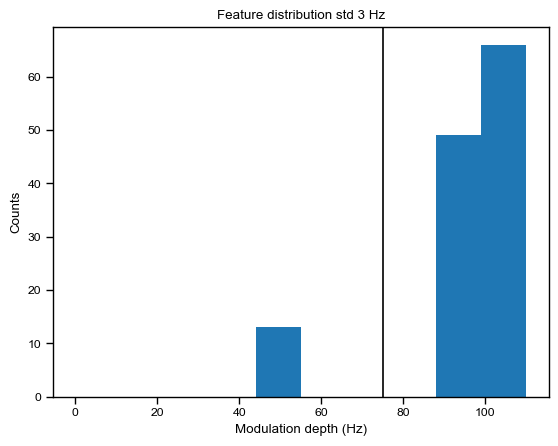

In [6]:


feature_weights = exp_data_all[0]['feature_selection']['feature_weights']
# plot the histogram of the feature weights

fig_weight, ax_weight = plt.subplots()
ax_weight.hist(feature_weights, range = (0,110))
ax_weight.axvline(x = 75, color = 'k')
ax_weight.set_xlabel('Modulation depth (Hz)')
ax_weight.set_ylabel('Counts')
ax_weight.set_title(f'Feature distribution std {std} Hz')

## check between conditions

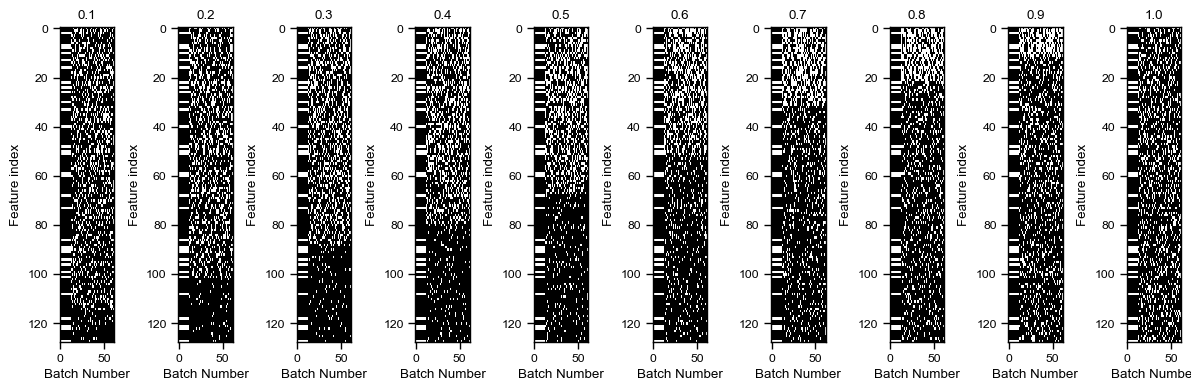

In [7]:
import importlib 
from afs_plotting import plot_feature_selection

num_columns = len(fraction_of_neurons_array)

fig_feat_activity, ax_feat_activity = plt.subplots(1, num_columns,
                                                   figsize = (12, 4))



for i, (e, a, s) in enumerate(zip(exp_data_all,  ax_feat_activity, fraction_of_neurons_array)):
    plot_feature_selection(e['feature_selection']['feat_set'], ax = a)
    
    #only title the exp if there are three exp, right. 
    a.set_title(np.round(s, decimals = ROUND_DECIMALS))

fig_feat_activity.tight_layout()


In [8]:
fraction_of_neurons_array

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [10]:
# next question I ask,  how many features are being selected, anyway? 
num_features_exp_by_batch = []
selected_feature_batches = [exp_data_all[i]['feature_selection']['feat_set'] for i in range(len(exp_data_all))]
for i,e in enumerate(exp_data_all):
    active_set = e['feature_selection']['feat_set']
    num_features_over_batch = np.sum(active_set, axis = 1)
    num_features_exp_by_batch.append(num_features_over_batch.copy())
    
# num_features_exp_by_batch = np.array(num_features_exp_by_batch)
# selected_feature_batches = np.array(selected_feature_batches)

In [11]:
for s in selected_feature_batches:
    print(s.shape)


smoothness_conds_by_batch = \
[calculate_feature_smoothness(s.T, mode = "incremental") for s in selected_feature_batches]

smoothness_conds_by_batch = np.array(smoothness_conds_by_batch)
print(smoothness_conds_by_batch.shape)

(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)
(62, 128)


In [12]:
# calculate the medians across the random seeds
print(smoothness_conds_by_batch.shape)
if len(random_seeds) > 1:
    smoothness_conds_by_batch_reshape = \
    np.reshape(smoothness_conds_by_batch,
                (len(random_seeds), 
                 len(smoothness_array), 
                 len(fraction_of_neurons_array), -1))
    
        # # after reshape,  we median along the random and first axiss
    print(smoothness_conds_by_batch_reshape.shape)
    smoothness_conds_by_batch_median = np.median(smoothness_conds_by_batch_reshape, axis = 0)

    # calculate the error bars based on the methodßß
    if error_bar_method == "sem":
        smoothness_conds_by_batch_sem = 1.25 * np.std(smoothness_conds_by_batch_reshape, axis = 0) / np.sqrt(len(random_seeds))

        smoothness_conds_by_batch_25 = smoothness_conds_by_batch_median - smoothness_conds_by_batch_sem
        smoothness_conds_by_batch_75 = smoothness_conds_by_batch_median + smoothness_conds_by_batch_sem
        print("used the sem method to calulate the error bar in smoothness")

    elif error_bar_method == "percentiles":
        # also calculate the 25 and 75 percentiles
        smoothness_conds_by_batch_25,  smoothness_conds_by_batch_75 =  \
        np.percentile(smoothness_conds_by_batch_reshape , 
                    [25, 75], 
                    axis = 0)
        print("used the percentiles to calulate the error bar in smoothness")
    else:
        raise ValueError("error bar method not recognized")
    

    # print out a message
    print("we reshaped the smoothness array")


    smoothness_conds_by_batch_ma_reshape = smoothness_conds_by_batch_median

print(smoothness_conds_by_batch.shape)
print(smoothness_conds_by_batch_25.shape)
print(smoothness_conds_by_batch_75.shape)


print(smoothness_conds_by_batch_ma_reshape.shape)




(120, 61)
(2, 6, 10, 61)
used the sem method to calulate the error bar in smoothness
we reshaped the smoothness array
(120, 61)
(6, 10, 61)
(6, 10, 61)
(6, 10, 61)


In [13]:
# # smooth the smoothness_conds_by_batch
# window_size = 10
# weights = np.ones(window_size) / window_size
# smoothness_conds_by_batch_ma = np.apply_along_axis(lambda x: np.convolve(x, weights, mode='valid'), 
#                                                    axis=1,
#                                                    arr=smoothness_conds_by_batch)
# smoothness_conds_by_batch_ma_reshape = \
# np.reshape(smoothness_conds_by_batch_ma, 
#            (len(smoothness_array), len(fraction_of_neurons_array), -1))

## importantly,  we need to flip the order of the smoothness_conds_by_batch_ma_reshape
## because we want the smoothness to be increasing from left to right
smoothness_conds_by_batch_ma_reshape = \
np.flip(smoothness_conds_by_batch_ma_reshape, axis = 1)

smoothness_conds_by_batch_ma_reshape_25 = \
np.flip(smoothness_conds_by_batch_25, axis = 1)

smoothness_conds_by_batch_ma_reshape_75 = \
np.flip(smoothness_conds_by_batch_75, axis = 1)

print(smoothness_conds_by_batch_ma_reshape_25.shape)
print(smoothness_conds_by_batch_ma_reshape_75.shape)


# ge the last batch of the smoothness_conds_by_batch_ma_reshape
last_x_number_of_batches = 5
smoothness_conds_by_batch_ma_reshape = \
np.mean(smoothness_conds_by_batch_ma_reshape[:, :, -last_x_number_of_batches:], axis = -1)

# get the last batches for 25 and 75th
smoothness_conds_by_batch_ma_reshape_25 = \
np.mean(smoothness_conds_by_batch_ma_reshape_25[:, :, -last_x_number_of_batches:], axis = -1)

smoothness_conds_by_batch_ma_reshape_75 = \
    np.mean(smoothness_conds_by_batch_ma_reshape_75[:,:, -last_x_number_of_batches:],axis = -1)



print(smoothness_conds_by_batch_ma_reshape.shape)
print(smoothness_conds_by_batch_ma_reshape_25.shape)
print(smoothness_conds_by_batch_ma_reshape_75.shape)

(6, 10, 61)
(6, 10, 61)
(6, 10)
(6, 10)
(6, 10)


In [14]:
smoothness_conds_by_batch_ma_reshape_25[0]

array([0.10213, 0.17867, 0.1791 , 0.18575, 0.23403, 0.19436, 0.15022,
       0.17851, 0.18467, 0.1736 ])

## PLOT: smoothness conditions

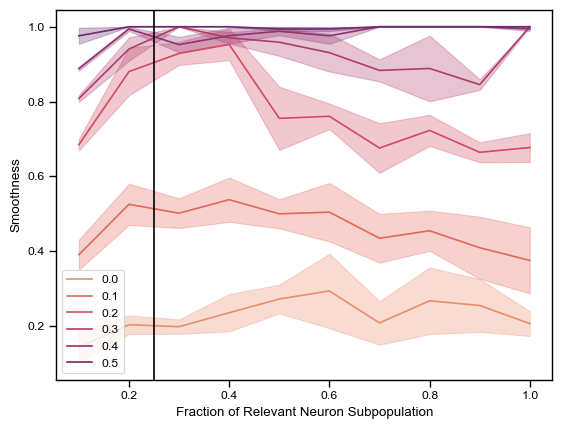

In [15]:
# make a figure that plots the smoothness

colors = sns.color_palette('flare', 
                           n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), 
                     smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
fig_smoothness, ax_smoothness = plt.subplots()

for i, (s, s_25, s_75, c) in enumerate(zip(smoothness_conds_by_batch_ma_reshape, 
                                           smoothness_conds_by_batch_ma_reshape_25,
                                           smoothness_conds_by_batch_ma_reshape_75, 
                                           
                               colors)):
    ax_smoothness.plot(fraction_of_neurons_array,
                       s, color = c, label = smoothness_array[i])
    
    # fill in between
    ax_smoothness.fill_between(fraction_of_neurons_array, 
                               s_25, 
                               s_75, color=c, alpha=0.3)

# draw a vertical line at set number of neurons
ax_smoothness.axvline(x = num_of_features / total_number_of_neurons, 
                      color = 'k')

ax_smoothness.set_xlabel('Fraction of Relevant Neuron Subpopulation')
ax_smoothness.set_ylabel('Smoothness')
ax_smoothness.legend()


# ax_smoothness.set_ylim([0.5, 1])

In [16]:
# next question I ask,  how many features are being selected, anyway? 
num_features_exp_by_batch = []

for i,e in enumerate(exp_data_all):

    active_set = e['feature_selection']['feat_set']

    num_features_over_batch = np.sum(active_set, axis = 1)
    num_features_exp_by_batch.append(num_features_over_batch.copy())

num_features_exp_by_batch = np.array(num_features_exp_by_batch)


# Behaviour comparision

## count how many rewards

In [17]:
fps = 60

reward_rate_all = list()
window_time_stamps_all = list()
NUM_EXP = len(exp_data_all)

total_rewards_all = list()

for i in range(NUM_EXP):

    time_stamps = exp_data_all[i]['events']['time'] / fps
    events = exp_data_all[i]['events']['event']
    
    num_rewards = np.count_nonzero(events == b'REWARD')

    (reward_rate, window_time_stamps) = aopy.analysis.calc_running_event_rate(b'REWARD', events, time_stamps, 
                                                                window_size= 120,
                                                                 window_step= 30)
    reward_rate_all.append(reward_rate)
    window_time_stamps_all.append(window_time_stamps)
    total_rewards_all.append(num_rewards)


window_stamps_all = np.array(window_time_stamps_all)
reward_rate_all = np.array(reward_rate_all) 
reward_rate_all = reward_rate_all.reshape((NUM_EXP,-1))
window_stamps_all = window_stamps_all.reshape((NUM_EXP,-1))

total_rewards_all = np.array(total_rewards_all)

print(reward_rate_all.shape)

(120, 16)


In [18]:
# average across the random seeds

if len(random_seeds) > 1:

    print("before reshape", reward_rate_all.shape  )
    # then we need to do reshape and median
    # assume that len(random_seeds) x len(smooth) = total number of exp
    reward_rate_all_reshape = np.reshape(reward_rate_all,
                                             (len(random_seeds), 
                                              len(smoothness_array), 
                                              len(fraction_of_neurons_array),
                                              -1))
    
    # # after reshape,  we median along the random and first axiss
    reward_rate_all_median = np.median(reward_rate_all_reshape, axis = 0)

    # print out a message
    # calculate the median across the random seeds, and the 25th, 75th percentiles
    # calculate the error bars based on the error_bar_method
    if error_bar_method == "sem":
        reward_rate_all_sem = np.std(reward_rate_all_reshape, axis = 0) / np.sqrt(len(random_seeds))
        reward_rate_all_25 = reward_rate_all_median - reward_rate_all_sem
        reward_rate_all_75 = reward_rate_all_median + reward_rate_all_sem
        print("used the sem method")
    elif error_bar_method == "percentiles":
        reward_rate_all_25, reward_rate_all_75 = np.percentile(reward_rate_all, [25, 75], axis = 0)
        print("used the percentiles method")

    reward_rate_all = np.median(reward_rate_all_reshape, axis = 0)


print(reward_rate_all.shape)
print(reward_rate_all.shape)
print(reward_rate_all_25.shape, reward_rate_all_75.shape)


before reshape (120, 16)
used the sem method
(6, 10, 16)
(6, 10, 16)
(6, 10, 16) (6, 10, 16)


In [19]:
num_reward_rates = reward_rate_all.shape[-1]
reward_rate_smooth_fraction = reward_rate_all

last_x_number_of_batches = 5

reward_rate_smooth_fraction_mean = \
np.mean(reward_rate_smooth_fraction[:,:,-last_x_number_of_batches:], axis = -1)

reward_rate_all_25_mean = \
    np.mean(reward_rate_all_25[:, :, -last_x_number_of_batches:], axis = -1)

reward_rate_all_75_mean = \
    np.mean(reward_rate_all_75[:,:,-last_x_number_of_batches:], axis = -1)

## this is important, we need to flip the reward_rate_smooth_fraction_mean along the fraction axis
## because we want to order the data in order of increasing fraction of good neurons
reward_rate_smooth_fraction_mean = np.flip(reward_rate_smooth_fraction_mean, axis = 1)
reward_rate_smooth_fraction_25_mean = np.flip(reward_rate_all_25_mean, axis = 1)
reward_rate_smooth_fraction_75_mean = np.flip(reward_rate_all_75_mean, axis = 1)

print(reward_rate_smooth_fraction.shape)
print(reward_rate_smooth_fraction_mean.shape)   



(6, 10, 16)
(6, 10)


## PLOT: of rewards as a function of fraction of good neurons (for each condition)

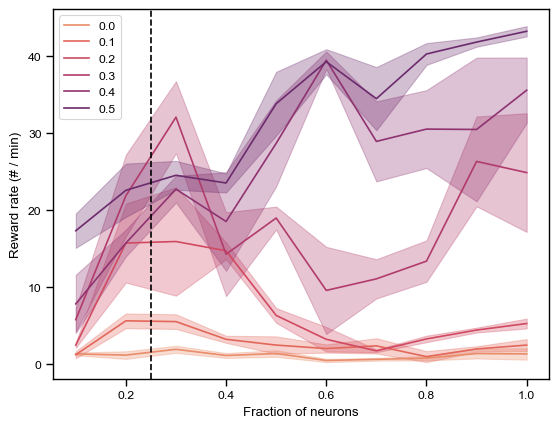

In [20]:
# plot the smoothness of the features
colors = sns.color_palette('flare', 
                           n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), 
                     smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)

fig_reward_rate, ax_reward_rate = plt.subplots()

for i, (r, r_25, r_75,  c) in enumerate(zip(reward_rate_smooth_fraction_mean, 
                               reward_rate_smooth_fraction_25_mean, 
                               reward_rate_smooth_fraction_75_mean,
                                colors)):
    ax_reward_rate.plot(fraction_of_neurons_array, r, color = c, label = smoothness_array[i])
    ax_reward_rate.fill_between(fraction_of_neurons_array, r_25, r_75, color = c, alpha = 0.3)
ax_reward_rate.set_xlabel('Fraction of neurons')
ax_reward_rate.set_ylabel('Reward rate (# / min)')
ax_reward_rate.legend()

# add a vertical dotted line to indicate the fraction of neurons that we are selecting
ax_reward_rate.axvline(x = num_of_features / total_number_of_neurons, 
                       color = 'k', linestyle = '--',
                       label = 'Set Number of Neurons')

## PLOT: a combined batch that compares smoothness and reward rate

# Summary Figure for Figure 4

(1, 3)


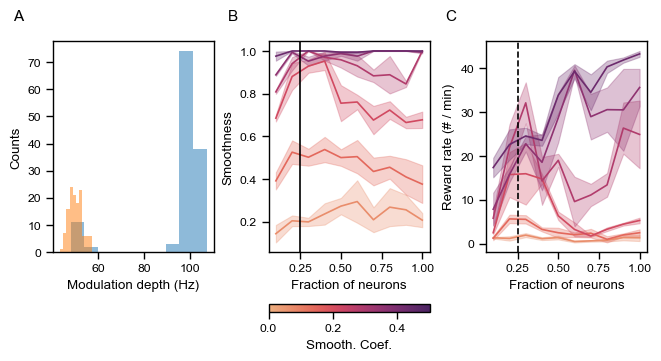

In [21]:
# we make a 4 by 4 figure

figure4, summary_axes = subplots_with_labels(1,3, figsize = (6.5, 3.5))

print(summary_axes.shape)

ax_weight = summary_axes[0,0]
feature_weights = exp_data_all[0]['feature_selection']['feature_weights']
ax_weight.hist(feature_weights, alpha = 0.5 )

feature_weights = exp_data_all[-1]['feature_selection']['feature_weights']
ax_weight.hist(feature_weights, alpha = 0.5 )
ax_weight.set_xlabel('Modulation depth (Hz)')
ax_weight.set_ylabel('Counts')


ax_smoothness = summary_axes[0, 1]
colors = sns.color_palette('flare', 
                           n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), 
                     smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)



for i, (s, s_25, s_75, c) in enumerate(zip(smoothness_conds_by_batch_ma_reshape, 
                                           smoothness_conds_by_batch_ma_reshape_25,
                                           smoothness_conds_by_batch_ma_reshape_75, 
                                           
                               colors)):
    ax_smoothness.plot(fraction_of_neurons_array,
                       s, color = c, label = smoothness_array[i])
    
    # fill in between
    ax_smoothness.fill_between(fraction_of_neurons_array, 
                               s_25, 
                               s_75, color=c, alpha=0.3)
# draw a vertical line at set number of neurons
ax_smoothness.axvline(x = num_of_features / total_number_of_neurons, 
                      color = 'k')

ax_smoothness.set_xlabel('Fraction of neurons')
ax_smoothness.set_ylabel('Smoothness')



ax_reward_rate = summary_axes[0,2]
for i, (r, r_25, r_75,  c) in enumerate(zip(reward_rate_smooth_fraction_mean, 
                               reward_rate_smooth_fraction_25_mean, 
                               reward_rate_smooth_fraction_75_mean,
                                colors)):
    ax_reward_rate.plot(fraction_of_neurons_array, r, color = c, label = smoothness_array[i])
    ax_reward_rate.fill_between(fraction_of_neurons_array, r_25, r_75, color = c, alpha = 0.3)
ax_reward_rate.set_xlabel('Fraction of neurons')
ax_reward_rate.set_ylabel('Reward rate (# / min)')

# add a vertical dotted line to indicate the fraction of neurons that we are selecting
ax_reward_rate.axvline(x = num_of_features / total_number_of_neurons, 
                       color = 'k', linestyle = '--',
                       label = 'Set Number of Neurons')

cbar = figure4.colorbar(sm, ax=summary_axes[0,1],
                 orientation='horizontal',
                 location = "bottom")
cbar.set_label('Smooth. Coef.')

# figure4.tight_layout()

## recombine data from the matrix plot

In [33]:
import pickle
# we load it and we plot it
# note the dict is loaded from 
# figure4_convex_algorithm_stationary_encoder/231019_afs_grid_random_start_smoothness_sparsity.ipynb

data_dump_folder = \
'/home/aolab/sijia/data/figure4_convex_stationary_encoder/'

num_of_feature_step =  16
num_of_features_array = list(range(8, n_neurons + 8, num_of_feature_step)) 

# we load the smooth and reward dict from the data_dump_folder 
with open(data_dump_folder + 'smooth_and_reward_dict.pkl', 'rb') as f:
    smooth_and_reward_dict = pickle.load(f)

smoothness_array = smooth_and_reward_dict['smoothness_array']
smoothness_last_reshape = smooth_and_reward_dict['smoothness_last_reshape']
smoothness_conds_by_batch_25  = smooth_and_reward_dict['smoothness_conds_by_batch_25']
smoothness_conds_by_batch_75 = smooth_and_reward_dict['smoothness_conds_by_batch_75']
reward_rate_final = smooth_and_reward_dict['reward_rate_final']
reward_rate_all_25 = smooth_and_reward_dict['reward_rate_all_25']
reward_rate_all_75 = smooth_and_reward_dict['reward_rate_all_75']

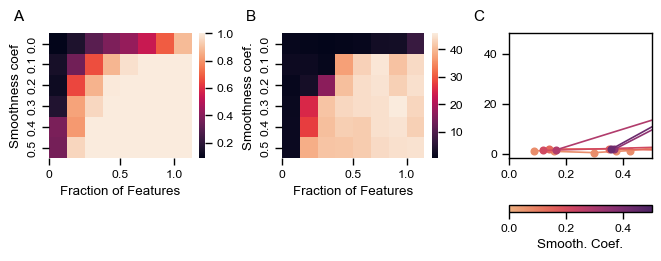

In [35]:
figure4, summary_axes = subplots_with_labels(1,3, 
                        figsize = (6.5, 2.5))

label_decimation_ratios = 8

num_of_features_fractions = np.array(num_of_features_array) / n_neurons

# top left, we plot smoothness
ax = summary_axes[0,0]
sns.heatmap(smoothness_last_reshape,
            ax = ax,
            yticklabels= smoothness_array)
ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
ax.set_xticklabels([0, 0.5, 1.0])
ax.set_ylabel('Smoothness coef')
ax.set_xlabel('Fraction of Features')


# bottom left, we plot the reward rate
ax = summary_axes[0,1]
sns.heatmap(reward_rate_final, 
            ax = ax,
            yticklabels= smoothness_array, 
            cbar = True)
ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
ax.set_xticklabels([0, 0.5, 1.0])
ax.set_xlabel('Fraction of Features')
ax.set_ylabel('Smoothness coef.')

# bottom right, we plot the relation between smoothness and reward rate
# we go down the row and make the plots
colors = sns.color_palette('flare', n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
ax = summary_axes[0,2]

for s, r, c in zip(smoothness_last_reshape, reward_rate_final, colors):
    ax.plot(s, r, "o-",color = c)

# limit the x-axis to [0,0.5]a
ax.set_xlim([0,0.5])

cbar = figure4.colorbar(sm, ax=summary_axes[0,2],
                 orientation='horizontal',
                 location = "bottom")
cbar.set_label('Smooth. Coef.')

In [36]:
len(colors), len(smoothness_last_reshape)

(6, 6)

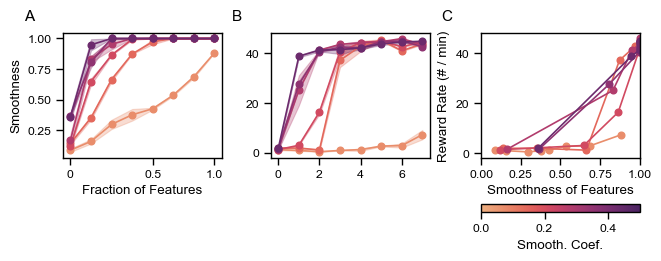

In [37]:
# we replot the previous figure using lineplots
# we replace the heatmaps with lineplots
figure4, summary_axes = subplots_with_labels(1,3, figsize = (6.5, 2.5))

label_decimation_ratios = 8

num_of_features_fractions = np.array(num_of_features_array) / n_neurons

# top left, we plot smoothness
ax = summary_axes[0,0]
for s,s_25, s_75, c in zip(smoothness_last_reshape, 
                           smoothness_conds_by_batch_25,
                            smoothness_conds_by_batch_75,
                           colors):
    ax.plot( s, "o-", color = c)
    ax.fill_between(np.arange(len(s)),
                    s_25, s_75, color = c, alpha = 0.3)

ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
ax.set_xticklabels([0, 0.5, 1.0])
ax.set_ylabel('Smoothness')
ax.set_xlabel('Fraction of Features')


# bottom left, we plot the reward rate
ax = summary_axes[0,1]
for r,r_25, r_75, c in zip(reward_rate_final, 
                            reward_rate_all_25,
                             reward_rate_all_75,
                           colors):
    ax.plot( r, "o-", color = c)
    ax.fill_between(np.arange(len(r)),
                    r_25, r_75, color = c, alpha = 0.3)


# bottom right, we plot the relation between smoothness and reward rate
# we go down the row and make the plots
colors = sns.color_palette('flare', n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
ax = summary_axes[0,2]

for s, r, c in zip(smoothness_last_reshape, reward_rate_final, colors):
    ax.plot(s, r, "o-",color = c)
ax.set_xlabel('Smoothness of Features')
ax.set_ylabel('Reward Rate (# / min)')


# limit the x-axis to [0,0.5]a
ax.set_xlim([0,1.0])

cbar = figure4.colorbar(sm, ax=summary_axes[0,2],
                 orientation='horizontal',
                 location = "bottom")
cbar.set_label('Smooth. Coef.')

## Summary Figure after recombination

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


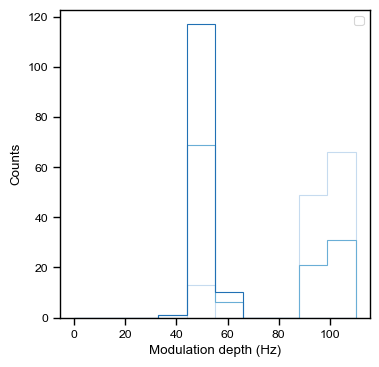

In [38]:
# make a random figure to figure out the staircase plot 
# this is for plotting the staircase plot
# pick an intermediate smoothness

feature_weights_indices = [0,5, 9]
# make a colormap that increases the color 
colors = sns.color_palette('Blues', n_colors=len(feature_weights_indices))


fig_stair, ax_stair = plt.subplots(1, 1, figsize = (4, 4))

feature_weights_all = []

# we collect all the feature weights 
for i, (f, c) in enumerate(zip(feature_weights_indices, colors)):
    feature_weights_all.append(exp_data_all[f]['feature_selection']['feature_weights'])


for i, (f, c) in enumerate(zip(feature_weights_indices, colors)):
    feature_weights = exp_data_all[f]['feature_selection']['feature_weights']
    stair_graph_values = np.histogram(feature_weights, 
                                      range = (0,110),
                                      )
    ax_stair.stairs(stair_graph_values[0],
                    edges = stair_graph_values[1],
                    color = c,
                    )
    
ax_stair.set_xlabel('Modulation depth (Hz)')
ax_stair.set_ylabel('Counts')
ax_stair.legend()
    

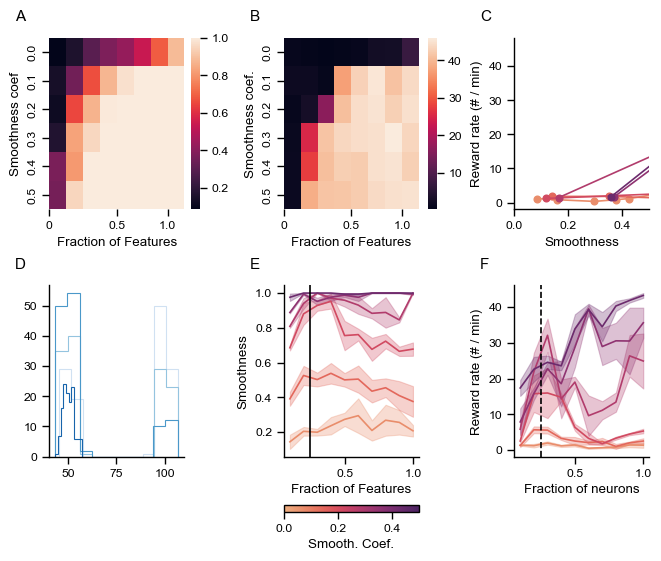

In [39]:
# Summary Figure for Figure 4

figure4, summary_axes_matrix_encoder_sweep = subplots_with_labels(2,3, figsize = (6.5, 5.5))

# the first row is the matrix plot
summary_axes = summary_axes_matrix_encoder_sweep[0,:][np.newaxis,:] 
label_decimation_ratios = 8

num_of_features_fractions = np.array(num_of_features_array) / n_neurons

# top left, we plot smoothness
ax = summary_axes[0,0]
sns.heatmap(smoothness_last_reshape,
            ax = ax,
            yticklabels= smoothness_array)
ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
ax.set_xticklabels([0, 0.5, 1.0])
ax.set_ylabel('Smoothness coef')
ax.set_xlabel('Fraction of Features')


# bottom left, we plot the reward rate
ax = summary_axes[0,1]
sns.heatmap(reward_rate_final, 
            ax = ax,
            yticklabels= smoothness_array, 
            cbar = True)
ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
ax.set_xticklabels([0, 0.5, 1.0])
ax.set_xlabel('Fraction of Features')
ax.set_ylabel('Smoothness coef.')

# bottom right, we plot the relation between smoothness and reward rate
# we go down the row and make the plots
colors = sns.color_palette('flare', n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
ax = summary_axes[0,2]

for s, r, c in zip(smoothness_last_reshape, reward_rate_final, colors):
    ax.plot(s, r, "o-",color = c)

# limit the x-axis to [0,0.5]a
ax.set_xlim([0,0.5])
ax.set_xlabel('Smoothness')
ax.set_ylabel('Reward rate (# / min)')


# SECOND ROW is the encoder sweep
summary_axes = summary_axes_matrix_encoder_sweep[1,:][np.newaxis,:]

ax_stair = summary_axes[0,0]
feature_weights_indices = [3, 5, 7, 9]
# make a colormap that increases the color 
colors = sns.color_palette('Blues', n_colors=len(feature_weights_indices))

for i, (f, c) in enumerate(zip(feature_weights_indices, colors)):
    feature_weights = exp_data_all[f]['feature_selection']['feature_weights']
    stair_graph_values = np.histogram(feature_weights, bins = 10)
    ax_stair.stairs(stair_graph_values[0],
                edges = stair_graph_values[1],
                color = c)



ax_smoothness = summary_axes[0, 1]
colors = sns.color_palette('flare', 
                           n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), 
                     smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)



for i, (s, s_25, s_75, c) in enumerate(zip(smoothness_conds_by_batch_ma_reshape, 
                                           smoothness_conds_by_batch_ma_reshape_25,
                                           smoothness_conds_by_batch_ma_reshape_75, 
                                           
                               colors)):
    ax_smoothness.plot(fraction_of_neurons_array,
                       s, color = c, label = smoothness_array[i])
    
    # fill in between
    ax_smoothness.fill_between(fraction_of_neurons_array, 
                               s_25, 
                               s_75, color=c, alpha=0.3)
# draw a vertical line at set number of neurons
ax_smoothness.axvline(x = num_of_features / total_number_of_neurons, 
                      color = 'k')

ax_smoothness.set_xlabel('Fraction of Features')
ax_smoothness.set_ylabel('Smoothness')



ax_reward_rate = summary_axes[0,2]
for i, (r, r_25, r_75,  c) in enumerate(zip(reward_rate_smooth_fraction_mean, 
                               reward_rate_smooth_fraction_25_mean, 
                               reward_rate_smooth_fraction_75_mean,
                                colors)):
    ax_reward_rate.plot(fraction_of_neurons_array, r, color = c, label = smoothness_array[i])
    ax_reward_rate.fill_between(fraction_of_neurons_array, r_25, r_75, color = c, alpha = 0.3)
ax_reward_rate.set_xlabel('Fraction of neurons')
ax_reward_rate.set_ylabel('Reward rate (# / min)')

# add a vertical dotted line to indicate the fraction of neurons that we are selecting
ax_reward_rate.axvline(x = num_of_features / total_number_of_neurons, 
                       color = 'k', linestyle = '--',
                       label = 'Set Number of Neurons')



cbar = figure4.colorbar(sm, ax=summary_axes[0,1],
                 orientation='horizontal',
                 location = "bottom")
cbar.set_label('Smooth. Coef.')

# make all ax. grid off,
# make the axis frame off

for ax in summary_axes_matrix_encoder_sweep.flatten():
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

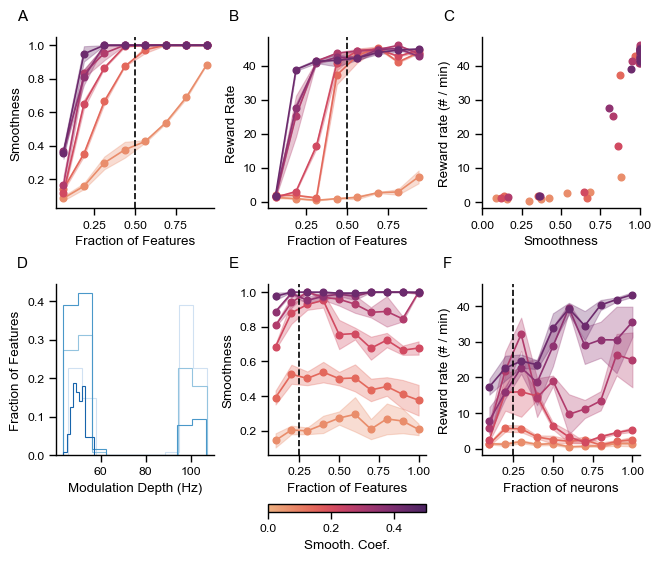

In [40]:

figure4, summary_axes_matrix_encoder_sweep = subplots_with_labels(2,3, figsize = (6.5, 5.5))

# the first row is the matrix plot
summary_axes = summary_axes_matrix_encoder_sweep[0,:][np.newaxis,:] 
label_decimation_ratios = 8

num_of_features_fractions = np.array(num_of_features_array) / n_neurons

# top left, we plot smoothness
ax = summary_axes[0,0]
for s,s_25, s_75, c in zip(smoothness_last_reshape, 
                           smoothness_conds_by_batch_25,
                            smoothness_conds_by_batch_75,
                           colors):
    ax.plot(num_of_features_fractions,  s, "o-", color = c)
    ax.fill_between(num_of_features_fractions,
                    s_25, s_75, color = c, alpha = 0.3)

# ax.set_xticks([0, len(num_of_features_fractions) // 2, len(num_of_features_fractions) - 1])
# ax.set_xticklabels([0, 0.5, 1.0])
ax.set_ylabel('Smoothness')
ax.set_xlabel('Fraction of Features')
ax.axvline(x = 0.5, color = 'k',
           linestyle = '--') # 64 is the size of the relevant neuron subpopulation



# bottom left, we plot the reward rate
ax = summary_axes[0,1]
for r,r_25, r_75, c in zip(reward_rate_final, 
                            reward_rate_all_25,
                             reward_rate_all_75,
                           colors):
    ax.plot(num_of_features_fractions,  r, "o-", color = c)
    ax.fill_between(num_of_features_fractions,
                    r_25, r_75, color = c, alpha = 0.3)
# ax.set_xticks([0, len(num_of_features_fractions) // 2, 
#                len(num_of_features_fractions) - 1])

# ax.set_xticklabels([0, 0.5, 1.0])
ax.set_xlabel('Fraction of Features')
ax.set_ylabel('Reward Rate')
ax.axvline(x = 0.5, color = 'k',
           linestyle = '--') # 64 is the size of the relevant neuron subpopulation


# bottom right, we plot the relation between smoothness and reward rate
# we go down the row and make the plots
colors = sns.color_palette('flare', n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)
ax = summary_axes[0,2]

for s, r, c in zip(smoothness_last_reshape, reward_rate_final, colors):
    ax.plot(s, r, "o",color = c)

# limit the x-axis to [0,0.5]a
ax.set_xlim([0,1.0])
ax.set_xlabel('Smoothness')
ax.set_ylabel('Reward rate (# / min)')


# SECOND ROW is the encoder sweep
summary_axes = summary_axes_matrix_encoder_sweep[1,:][np.newaxis,:]

ax_weight = summary_axes[0,0]
feature_weights_indices = [3, 5, 7, 9]
# make a colormap that increases the color 
colors = sns.color_palette('Blues', n_colors=len(feature_weights_indices))

for i, (f, c) in enumerate(zip(feature_weights_indices, colors)):
    feature_weights = exp_data_all[f]['feature_selection']['feature_weights']
    stair_graph_values = np.histogram(feature_weights, bins = 10)
    ax_weight.stairs(stair_graph_values[0] / 128,
                edges = stair_graph_values[1],
                color = c)
ax_weight.set_xlabel('Modulation Depth (Hz)')
ax_weight.set_ylabel('Fraction of Features')
s


ax_smoothness = summary_axes[0, 1]
colors = sns.color_palette('flare', 
                           n_colors=len(smoothness_array))
norm = plt.Normalize(smoothness_array.min(), 
                     smoothness_array.max())
sm = plt.cm.ScalarMappable(cmap="flare", norm=norm)



for i, (s, s_25, s_75, c) in enumerate(zip(smoothness_conds_by_batch_ma_reshape, 
                                           smoothness_conds_by_batch_ma_reshape_25,
                                           smoothness_conds_by_batch_ma_reshape_75, 
                                           
                               colors)):
    ax_smoothness.plot(fraction_of_neurons_array,   
                       s, "-o",
                       color = c, label = smoothness_array[i])
    
    # fill in between
    ax_smoothness.fill_between(fraction_of_neurons_array, 
                               s_25, 
                               s_75, color=c, alpha=0.3)
# draw a vertical line at set number of neurons
ax_smoothness.axvline(x = num_of_features / total_number_of_neurons, 
                      color = 'k',
                      linestyle = '--')

ax_smoothness.set_xlabel('Fraction of Features')
ax_smoothness.set_ylabel('Smoothness')



ax_reward_rate = summary_axes[0,2]
for i, (r, r_25, r_75,  c) in enumerate(zip(reward_rate_smooth_fraction_mean, 
                               reward_rate_smooth_fraction_25_mean, 
                               reward_rate_smooth_fraction_75_mean,
                                colors)):
    ax_reward_rate.plot(fraction_of_neurons_array, r, 
                        "-o",
                        color = c, label = smoothness_array[i])
    ax_reward_rate.fill_between(fraction_of_neurons_array, r_25, r_75, color = c, alpha = 0.3)
ax_reward_rate.set_xlabel('Fraction of neurons')
ax_reward_rate.set_ylabel('Reward rate (# / min)')

# add a vertical dotted line to indicate the fraction of neurons that we are selecting
ax_reward_rate.axvline(x = num_of_features / total_number_of_neurons, 
                       color = 'k', linestyle = '--',
                       label = 'Set Number of Neurons')



cbar = figure4.colorbar(sm, ax=summary_axes[0,1],
                 orientation='horizontal',
                 location = "bottom")
cbar.set_label('Smooth. Coef.')

# make all ax. grid off,
# make the axis frame off

for ax in summary_axes_matrix_encoder_sweep.flatten():
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# rearrange the figure so it makes alightly more sense. 

### save to gdrive

In [41]:
if save_to_gdrive:
    figure4.savefig(gdrive_directory + 'figure7_fraction_neuron_scan.pdf', dpi = dpi_value)
    figure4.savefig(gdrive_directory + 'figure7_fraction_neuron_scan.png', dpi = dpi_value)
    figure4.savefig(gdrive_directory + 'figure7_fraction_neuron_scan.svg', dpi = dpi_value)